# Marketing Analytics: Campaign Performance and Customer Response Analysis

## 1. Business Problem

Marketing teams invest significant resources in campaigns to acquire customers, improve engagement, and increase conversions. However, not all campaigns perform equally well, and customer response often varies based on demographics, spending behavior, and communication channels.

This project analyzes marketing data to understand customer behavior, evaluate campaign performance, and identify the factors that influence customer response. The goal is to generate insights that help improve targeting, campaign effectiveness, and overall marketing decision-making.

## 2. Project Objectives

- To understand the structure and quality of the marketing dataset
- To analyze customer demographic and spending patterns
- To evaluate campaign response and customer engagement
- To identify factors associated with higher customer acceptance
- To generate business insights for improving future marketing strategies

## 3. Import Libraries

In [6]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

## 4. Load Dataset

In [7]:
file_path = r"C:\Users\vasis\Desktop\Data_Analytics_Portfolio\03_Marketing_Analytics\data_raw\marketing_campaign_raw.csv"
df = pd.read_csv(file_path)

## 5. Initial Data Inspection

In [8]:
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
df.describe()
# Statistical summary for categorical columns
df.describe(include=['object','string'])

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


In [9]:
df.shape


(11162, 17)

In [10]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'deposit']

In [11]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['deposit'].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [14]:
df['deposit'].value_counts(normalize=True) * 100

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64

## 6. Dataset Overview

The dataset consists of 11,162 customer records and 17 variables related to demographic background, financial condition, communication method, and past marketing interactions. The target variable is `deposit`, which indicates whether the customer subscribed to a term deposit.

The dataset is well-structured and does not show apparent missing values, making it suitable for exploratory data analysis and marketing insight generation.

## 7. Exploratory Data Analysis
## 8. Target Variable Overview

The target variable `deposit` indicates whether a customer subscribed to the term deposit campaign. The class distribution is relatively balanced, with approximately 52.62% of customers not subscribing and 47.38% subscribing. This balanced distribution supports meaningful comparative analysis between converted and non-converted customers.

In [15]:
# Numerical and categorical columns

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object', 'string']).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


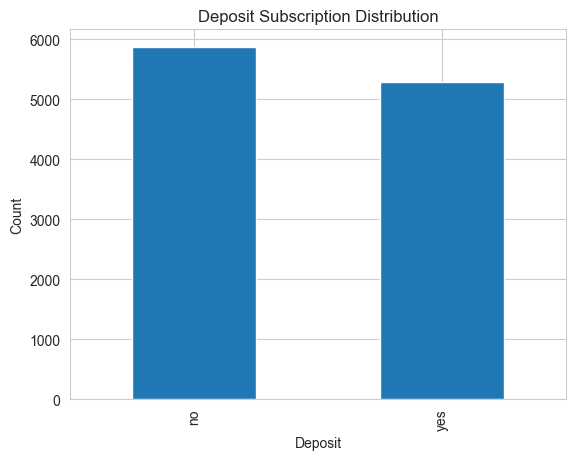

In [16]:
# Deposit distribution
df['deposit'].value_counts().plot(kind='bar')
plt.title('Deposit Subscription Distribution')
plt.xlabel('Deposit')
plt.ylabel('Count')
plt.show()

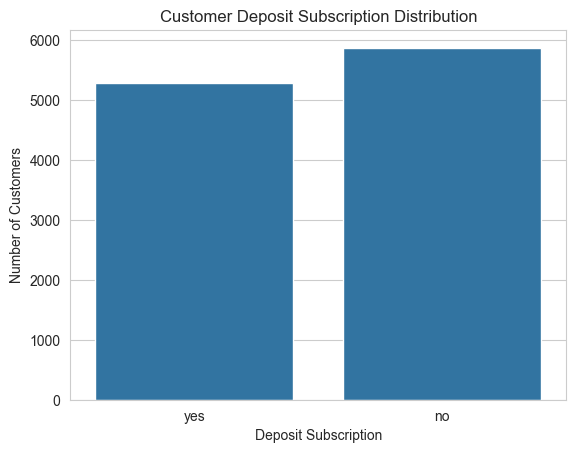

In [17]:
# Count plot for deposit
sns.countplot(data=df, x='deposit')
plt.title('Customer Deposit Subscription Distribution')
plt.xlabel('Deposit Subscription')
plt.ylabel('Number of Customers')
plt.show()

**Insight:** The deposit subscription outcome is relatively balanced, with a slightly higher proportion of customers not subscribing. This indicates that the campaign achieved a meaningful response level, making the dataset suitable for understanding the factors that influence customer conversion.

In [18]:
numerical_columns = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
numerical_columns

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [19]:
df[numerical_columns].describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


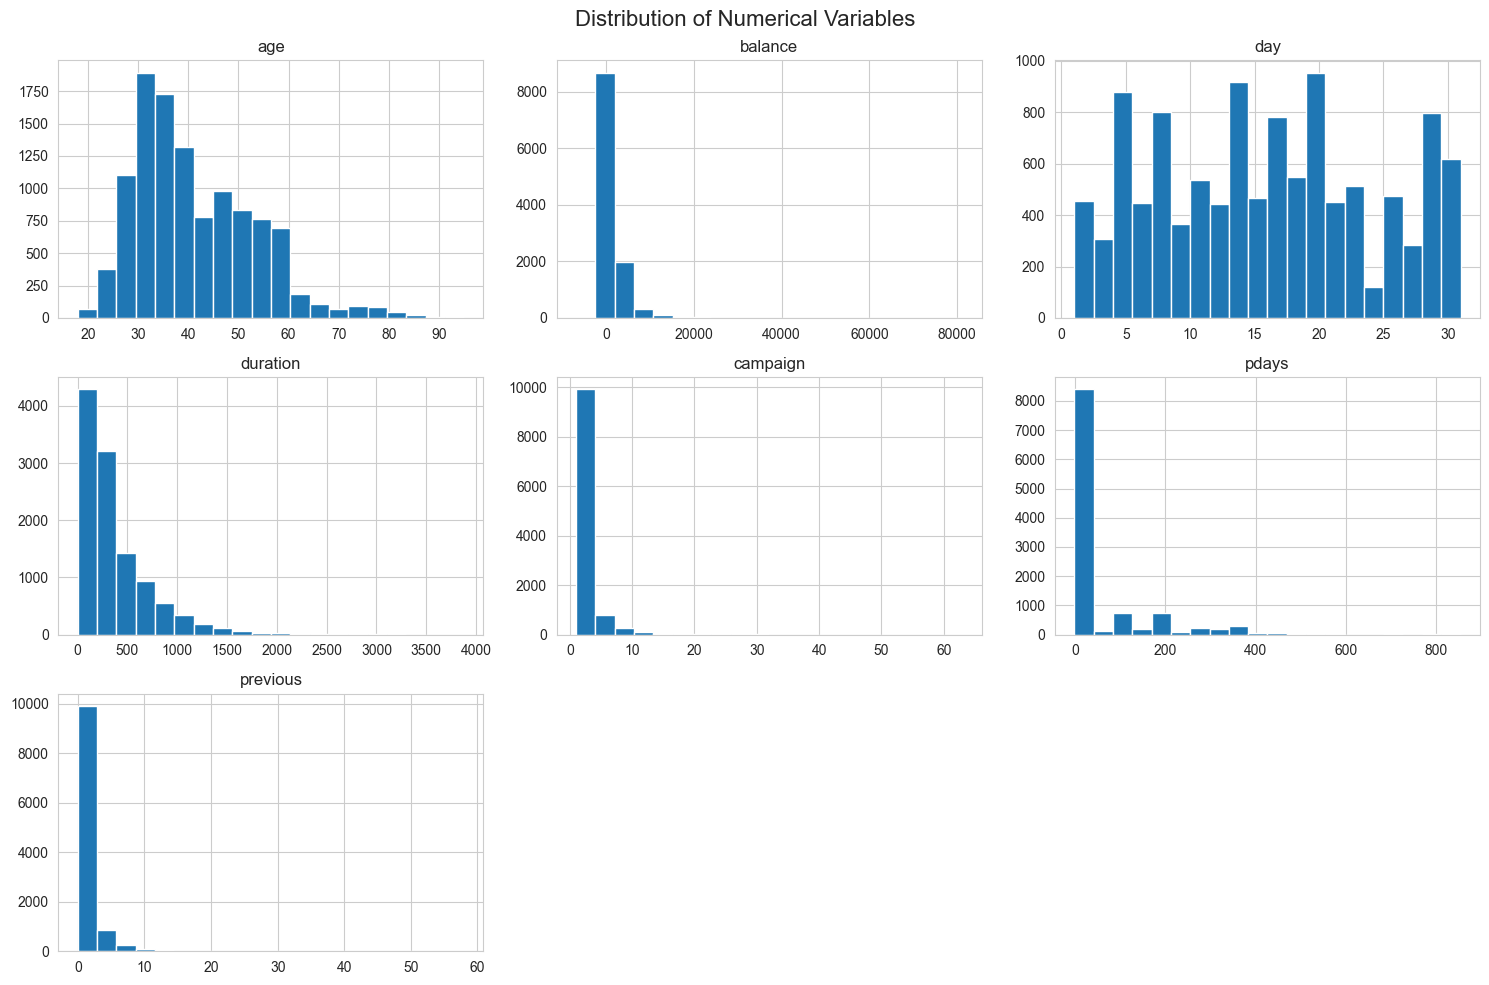

In [20]:
df[numerical_columns].hist(figsize=(15, 10), bins=20)
plt.suptitle('Distribution of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

## 9. Numerical Feature Analysis

Numerical variables provide important information about customer characteristics and campaign interaction patterns. Analyzing their distributions helps identify skewness, unusual values, and behavioral trends that may affect marketing response.

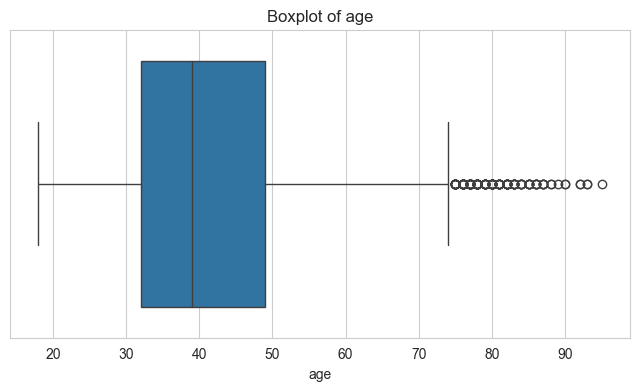

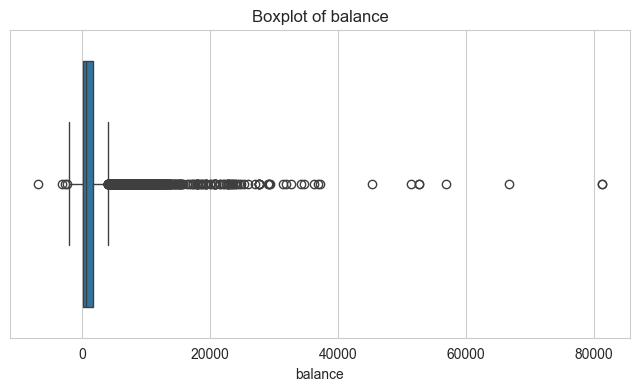

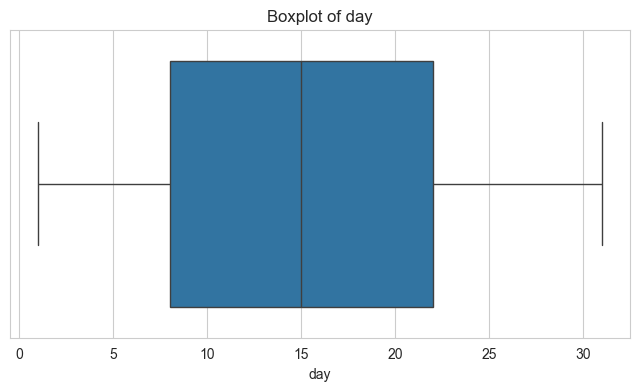

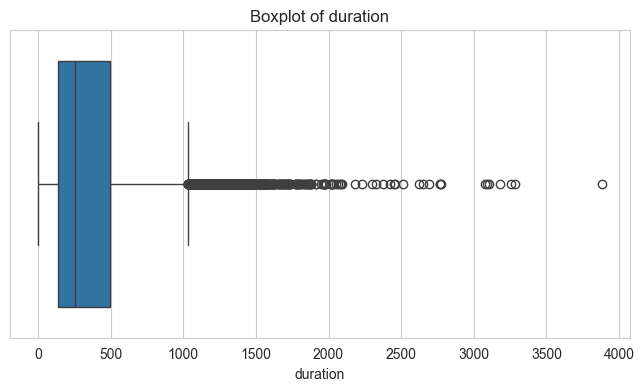

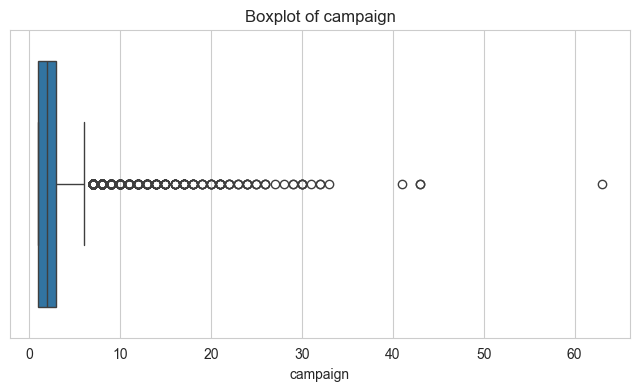

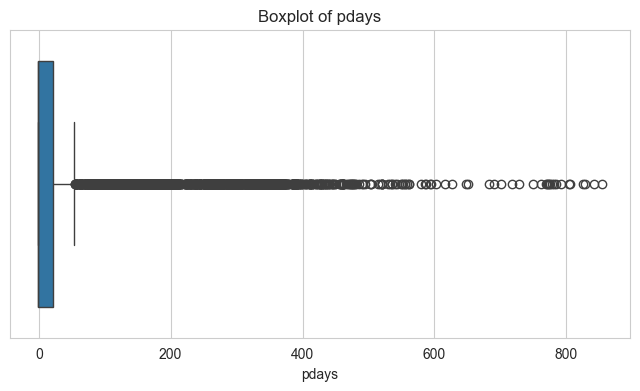

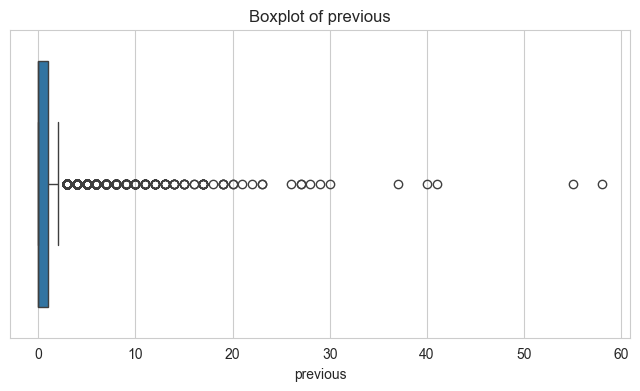

In [21]:
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [22]:
categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

In [23]:
for col in categorical_columns:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for job:
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

Value counts for marital:
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

Value counts for education:
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

Value counts for default:
default
no     10994
yes      168
Name: count, dtype: int64

Value counts for housing:
housing
no     5881
yes    5281
Name: count, dtype: int64

Value counts for loan:
loan
no     9702
yes    1460
Name: count, dtype: int64

Value counts for contact:
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

Value counts for month:
month
may    2824
aug    1519
jul    1514
j

## 10. Major categorical variables

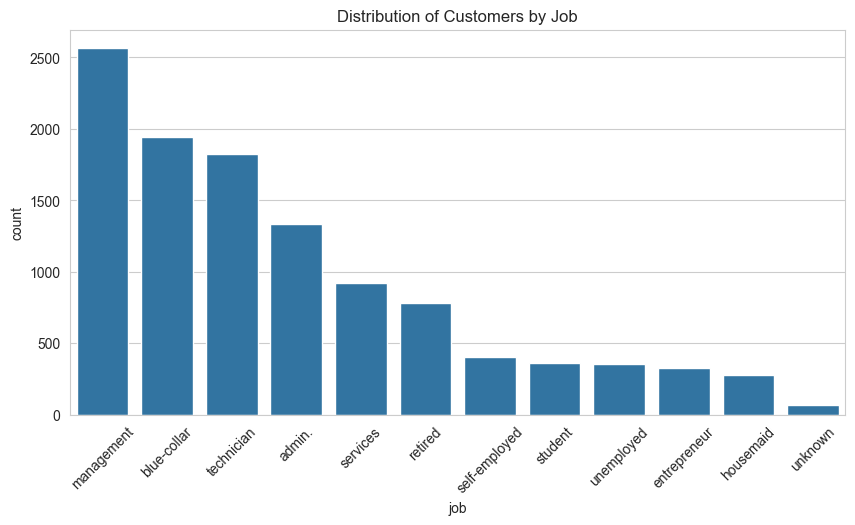

In [24]:
# Job
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='job', order=df['job'].value_counts().index)
plt.title('Distribution of Customers by Job')
plt.xticks(rotation=45)
plt.show()

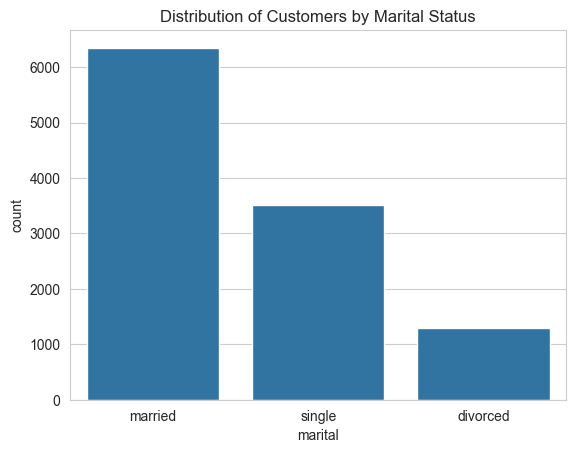

In [25]:
# Marital Status
sns.countplot(data=df, x='marital', order=df['marital'].value_counts().index)
plt.title('Distribution of Customers by Marital Status')
plt.show()

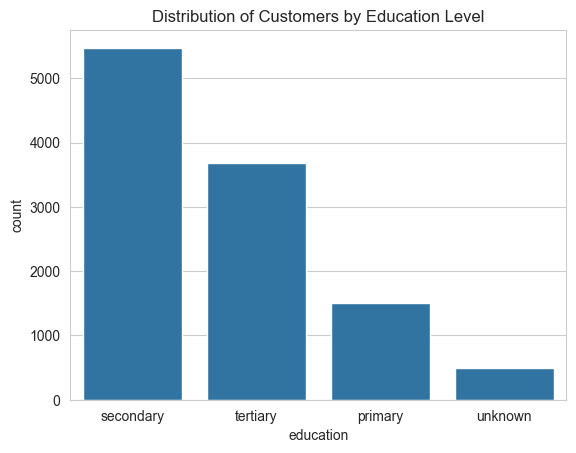

In [26]:
#Education
sns.countplot(data=df, x='education', order=df['education'].value_counts().index)
plt.title('Distribution of Customers by Education Level')
plt.show()

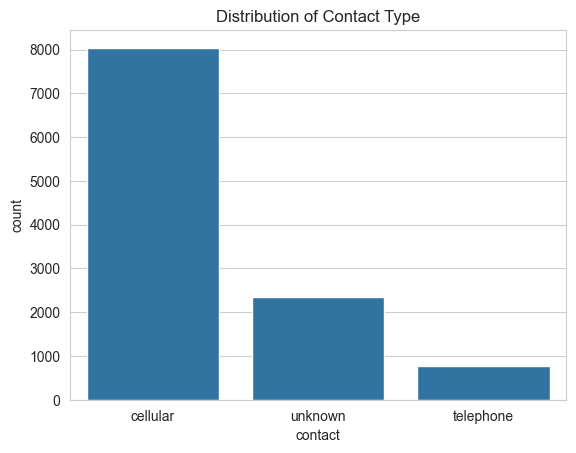

In [27]:
# Contact
sns.countplot(data=df, x='contact', order=df['contact'].value_counts().index)
plt.title('Distribution of Contact Type')
plt.show()

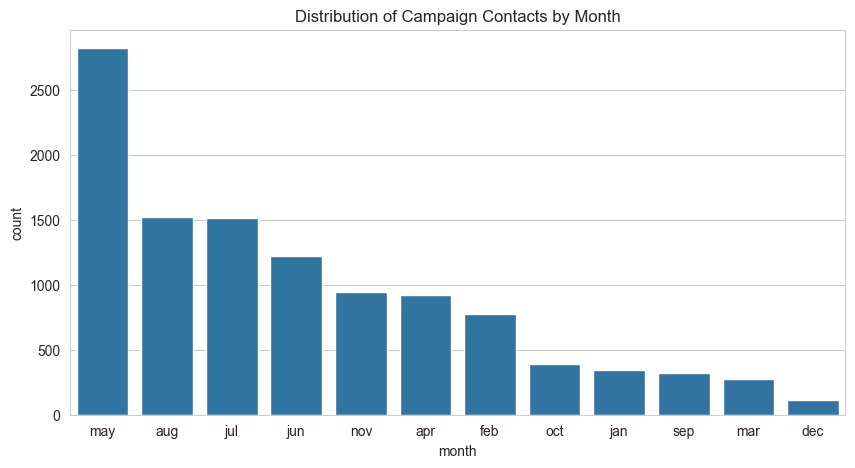

In [28]:
# Month
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='month', order=df['month'].value_counts().index)
plt.title('Distribution of Campaign Contacts by Month')
plt.show()

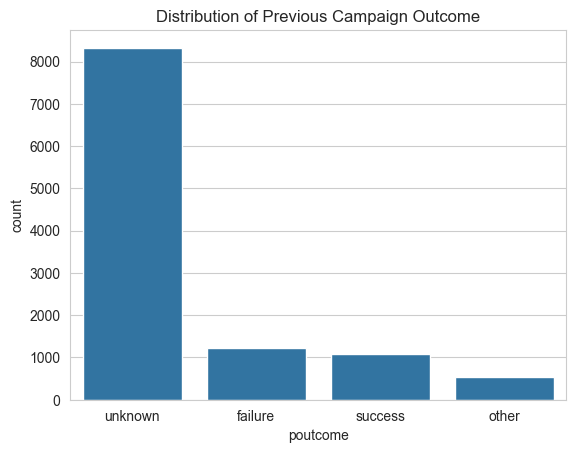

In [29]:
#Previous outcome
sns.countplot(data=df, x='poutcome', order=df['poutcome'].value_counts().index)
plt.title('Distribution of Previous Campaign Outcome')
plt.show()

## 11. Categorical Feature Analysis

Categorical variables help describe customer background, communication method, and previous campaign results. Understanding their distribution allows us to identify dominant customer segments and campaign patterns across the dataset.

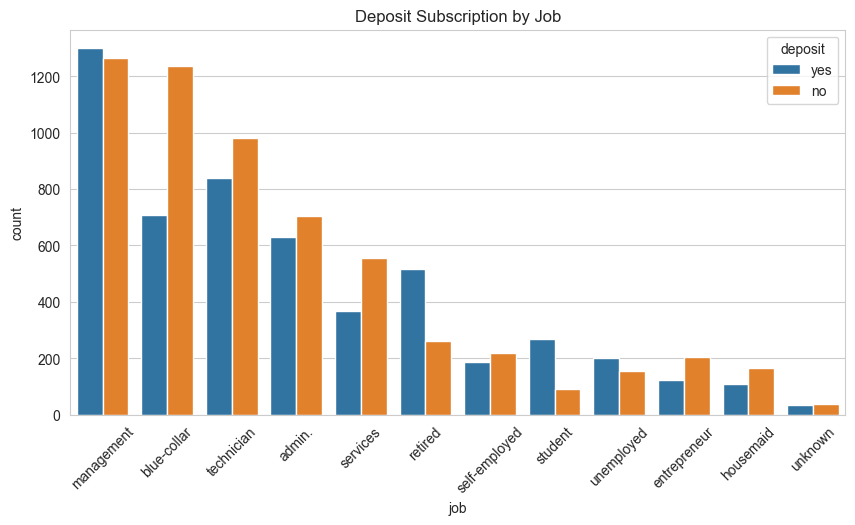

In [30]:
#Deposit by Job
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='job', hue='deposit', order=df['job'].value_counts().index)
plt.title('Deposit Subscription by Job')
plt.xticks(rotation=45)
plt.show()

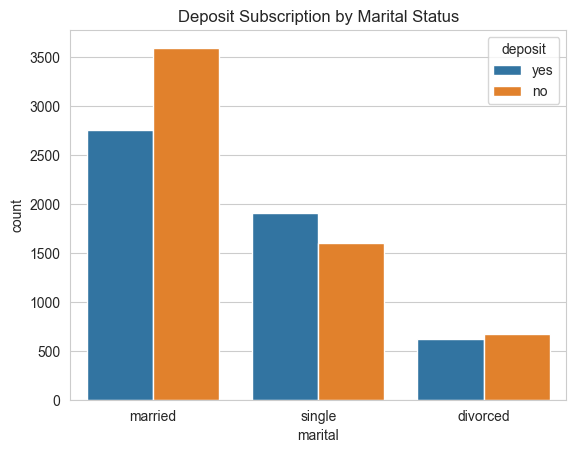

In [31]:
# Deposit by Marital Status
sns.countplot(data=df, x='marital', hue='deposit', order=df['marital'].value_counts().index)
plt.title('Deposit Subscription by Marital Status')
plt.show()

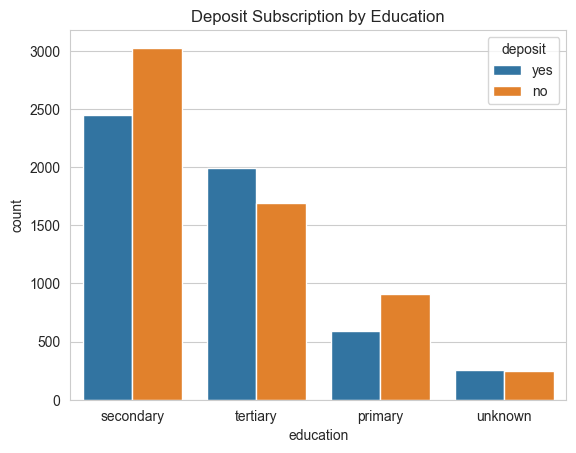

In [32]:
#Deposit by Education
sns.countplot(data=df, x='education', hue='deposit', order=df['education'].value_counts().index)
plt.title('Deposit Subscription by Education')
plt.show()

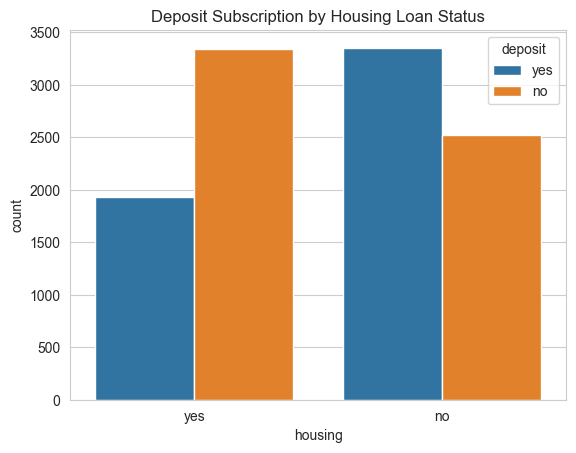

In [33]:
# Deposit by Housing Loan
sns.countplot(data=df, x='housing', hue='deposit')
plt.title('Deposit Subscription by Housing Loan Status')
plt.show()

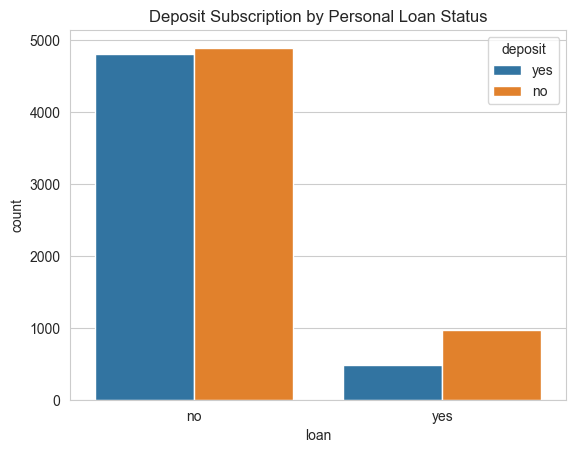

In [34]:
# Deposit by Personal Loan
sns.countplot(data=df, x='loan', hue='deposit')
plt.title('Deposit Subscription by Personal Loan Status')
plt.show()

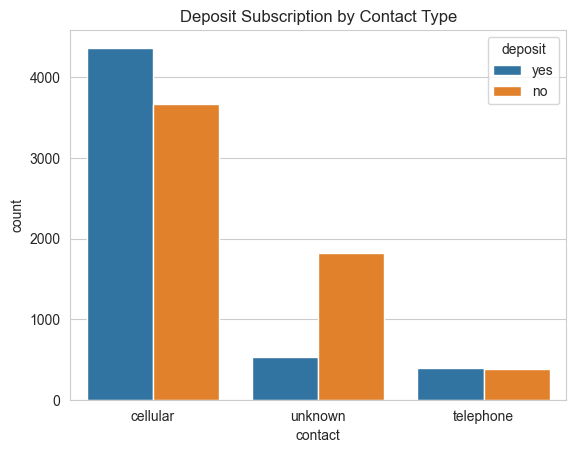

In [35]:
# Deposit by Contact Type
sns.countplot(data=df, x='contact', hue='deposit', order=df['contact'].value_counts().index)
plt.title('Deposit Subscription by Contact Type')
plt.show()

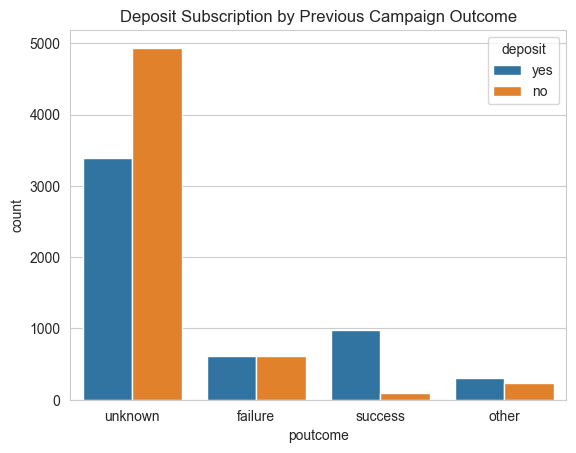

In [36]:
#Deposit by Previous Outcome
sns.countplot(data=df, x='poutcome', hue='deposit', order=df['poutcome'].value_counts().index)
plt.title('Deposit Subscription by Previous Campaign Outcome')
plt.show()

In [37]:
# Conversion rate by Job
job_conversion = pd.crosstab(df['job'], df['deposit'], normalize='index') * 100
job_conversion

deposit,no,yes
job,,
admin.,52.698651,47.301349
blue-collar,63.580247,36.419753
entrepreneur,62.500000,37.500000
housemaid,60.218978,39.781022
management,49.298519,50.701481
retired,33.676093,66.323907
self-employed,53.827160,46.172840
services,60.021668,39.978332
student,25.277778,74.722222


In [38]:
# Conversion rate by marital
marital_conversion = pd.crosstab(df['marital'], df['deposit'], normalize='index') * 100
marital_conversion

deposit,no,yes
marital,,
divorced,51.894818,48.105182
married,56.621005,43.378995
single,45.650938,54.349062


In [39]:
# Conversion rate  by education
education_conversion = pd.crosstab(df['education'], df['deposit'], normalize='index') * 100
education_conversion

deposit,no,yes
education,,
primary,60.600000,39.400000
secondary,55.259313,44.740687
tertiary,45.893196,54.106804
unknown,49.295775,50.704225


In [40]:
# Conversion rate by contact
contact_conversion = pd.crosstab(df['contact'], df['deposit'], normalize='index') * 100
contact_conversion

deposit,no,yes
contact,,
cellular,45.672718,54.327282
telephone,49.612403,50.387597
unknown,77.408355,22.591645


In [41]:
# Conversion rate by poutcome
poutcome_conversion = pd.crosstab(df['poutcome'], df['deposit'], normalize='index') * 100
poutcome_conversion

deposit,no,yes
poutcome,,
failure,49.674267,50.325733
other,42.830540,57.169460
success,8.683473,91.316527
unknown,59.332212,40.667788


## 12. Feature Engineering

In [42]:
#Age group
def age_group(age):
    if age < 30:
        return '18-29'
    elif age < 40:
        return '30-39'
    elif age < 50:
        return '40-49'
    elif age < 60:
        return '50-59'
    else:
        return '60+'

df['age_group'] = df['age'].apply(age_group)

In [43]:
#Balance group
def balance_group(balance):
    if balance < 0:
        return 'Negative Balance'
    elif balance == 0:
        return 'Zero Balance'
    elif balance <= 1000:
        return 'Low Balance'
    elif balance <= 5000:
        return 'Medium Balance'
    else:
        return 'High Balance'

df['balance_group'] = df['balance'].apply(balance_group)

In [44]:
# Campaign contact group
def campaign_group(campaign):
    if campaign == 1:
        return '1 Contact'
    elif campaign <= 3:
        return '2-3 Contacts'
    elif campaign <= 5:
        return '4-5 Contacts'
    else:
        return '6+ Contacts'

df['campaign_group'] = df['campaign'].apply(campaign_group)

### visualize conversion by these grouped variables

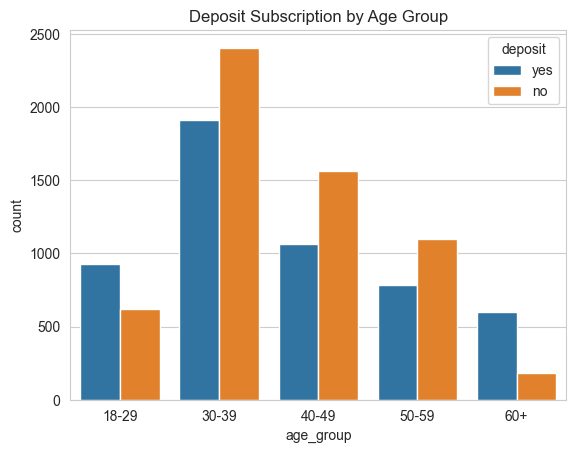

In [45]:
#Deposit by age group
sns.countplot(data=df, x='age_group', hue='deposit', order=['18-29', '30-39', '40-49', '50-59', '60+'])
plt.title('Deposit Subscription by Age Group')
plt.show()

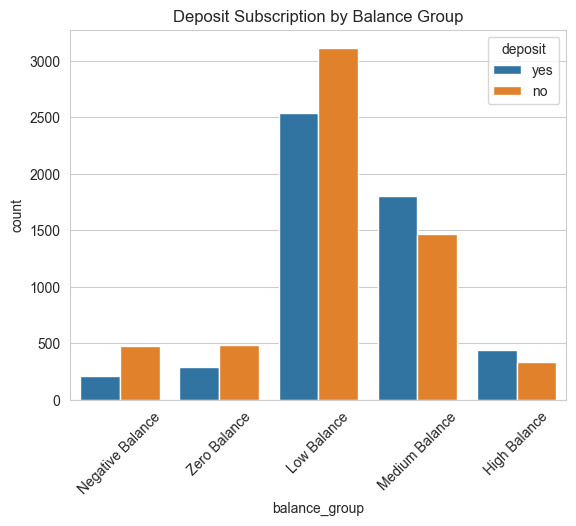

In [46]:
# Deposit by balance group
sns.countplot(data=df, x='balance_group', hue='deposit',
              order=['Negative Balance', 'Zero Balance', 'Low Balance', 'Medium Balance', 'High Balance'])
plt.title('Deposit Subscription by Balance Group')
plt.xticks(rotation=45)
plt.show()

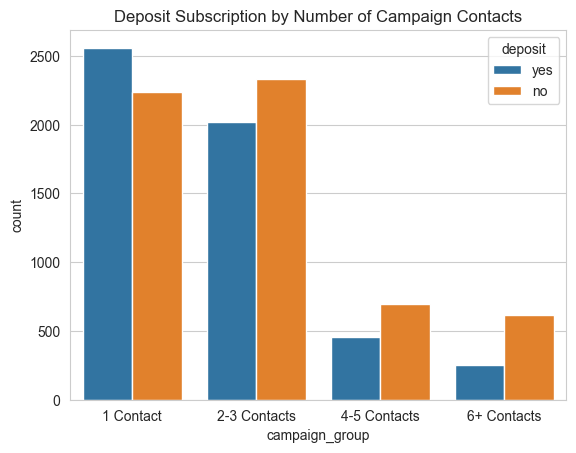

In [47]:
# Deposit by campaign group
sns.countplot(data=df, x='campaign_group', hue='deposit',
              order=['1 Contact', '2-3 Contacts', '4-5 Contacts', '6+ Contacts'])
plt.title('Deposit Subscription by Number of Campaign Contacts')
plt.show()

## 13. Numerical Feature Analysis

The numerical variables provide insights into customer demographics, financial status, and campaign interaction behavior. Key observations from the statistical summary are as follows:

- The average customer age is approximately 41 years, indicating a middle-aged customer base.
- The account balance shows high variability, with both negative and very high positive values, suggesting diverse financial conditions among customers.
- Call duration has a wide range, indicating that customer engagement levels during calls vary significantly.
- Most customers are contacted 1 to 3 times during a campaign, though a few cases show a very high number of contacts.
- The `pdays` variable contains many -1 values, indicating that a large number of customers were not contacted in previous campaigns.

In [48]:
df[numerical_columns].describe()


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [49]:
job_conversion

deposit,no,yes
job,,
admin.,52.698651,47.301349
blue-collar,63.580247,36.419753
entrepreneur,62.500000,37.500000
housemaid,60.218978,39.781022
management,49.298519,50.701481
retired,33.676093,66.323907
self-employed,53.827160,46.172840
services,60.021668,39.978332
student,25.277778,74.722222


### Conversion by Job

Customer conversion varies significantly across job categories. Students and retired customers show the highest conversion rates, while blue-collar and service-related jobs show relatively lower conversion.

This suggests that occupation plays a strong role in determining customer response to marketing campaigns.

**Business Insight:** Marketing efforts should prioritize students, retired individuals, and management professionals, as they demonstrate higher responsiveness to campaigns. Lower-performing segments such as blue-collar workers may require different messaging or targeting strategies.

In [50]:
marital_conversion

deposit,no,yes
marital,,
divorced,51.894818,48.105182
married,56.621005,43.378995
single,45.650938,54.349062


### Conversion by Marital Status

Single customers show the highest conversion rate, followed by divorced individuals, while married customers have the lowest conversion.

This indicates that lifestyle and financial decision-making patterns may influence campaign responsiveness.

In [51]:
education_conversion

deposit,no,yes
education,,
primary,60.600000,39.400000
secondary,55.259313,44.740687
tertiary,45.893196,54.106804
unknown,49.295775,50.704225


### Conversion by Education Level

Customers with higher education levels (tertiary) show better conversion rates compared to those with primary or secondary education.

This suggests that education level may influence financial awareness and responsiveness to investment-related campaigns.

In [52]:
contact_conversion

deposit,no,yes
contact,,
cellular,45.672718,54.327282
telephone,49.612403,50.387597
unknown,77.408355,22.591645


### Conversion by Contact Method

Customers contacted via cellular communication show significantly higher conversion rates compared to telephone and unknown contact methods.

Unknown contact type shows very low conversion, indicating ineffective or unclear communication channels.

**Business Insight:** Marketing campaigns should prioritize cellular communication channels, as they demonstrate significantly higher effectiveness. Avoiding unclear or untracked contact methods can improve overall campaign performance.

In [53]:
poutcome_conversion

deposit,no,yes
poutcome,,
failure,49.674267,50.325733
other,42.830540,57.169460
success,8.683473,91.316527
unknown,59.332212,40.667788


### Conversion by Previous Campaign Outcome

Customers who previously responded successfully to campaigns show extremely high conversion rates in current campaigns. In contrast, customers with unknown or no prior success show significantly lower conversion.

This highlights the importance of historical customer interaction in predicting future campaign success.

**Business Insight:** Customers with a history of successful campaign interaction should be prioritized for future campaigns, as they are significantly more likely to convert. Leveraging past success data can greatly improve marketing efficiency.

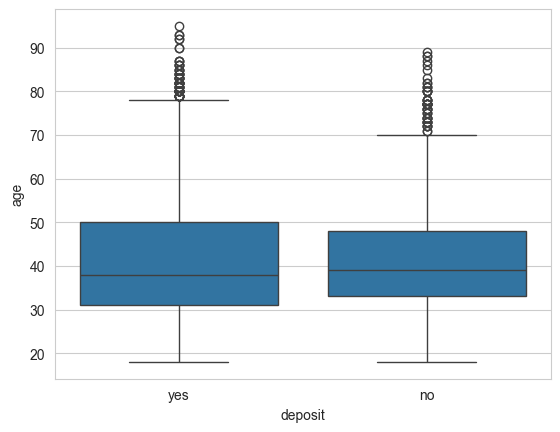

In [54]:
sns.boxplot(data=df, x='deposit', y='age')
plt.show()

### Age and Deposit Subscription

The boxplot indicates that customers who subscribed to the deposit tend to have slightly higher age values compared to those who did not subscribe. This suggests that older customers may be relatively more responsive to the campaign.

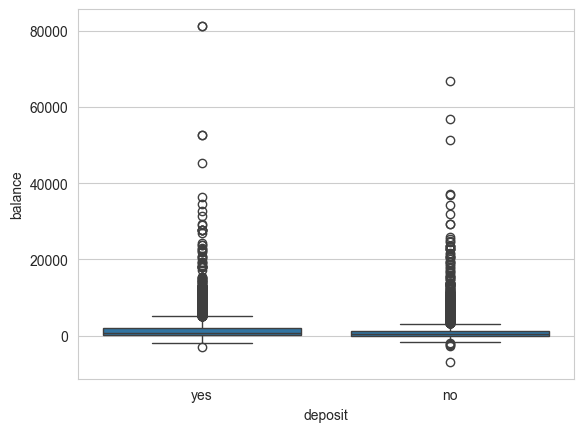

In [55]:
sns.boxplot(data=df, x='deposit', y='balance')
plt.show()

### Balance and Deposit Subscription

Customers who subscribed to the deposit generally show higher account balances compared to non-subscribers. This suggests that financially stronger customers may be more willing or able to invest in term deposit products.

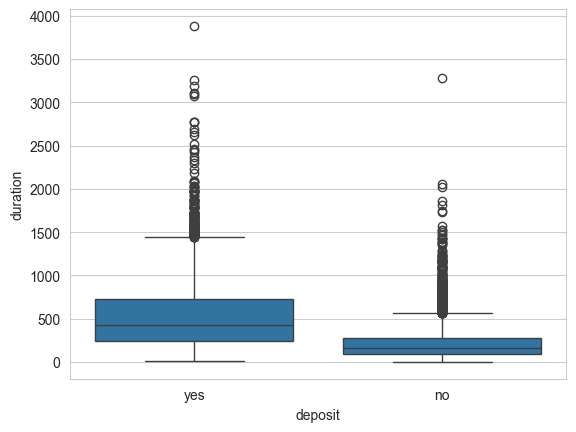

In [56]:
sns.boxplot(data=df, x='deposit', y='duration')
plt.show()

### Call Duration and Deposit Subscription

Call duration is noticeably higher for customers who subscribed to the deposit. This indicates that longer conversations are strongly associated with higher conversion.

A longer interaction may reflect stronger customer interest, better engagement, or more effective communication during the campaign.

**Note:** While call duration is highly associated with conversion, it is more useful for evaluating campaign effectiveness after customer contact rather than for pre-contact targeting.

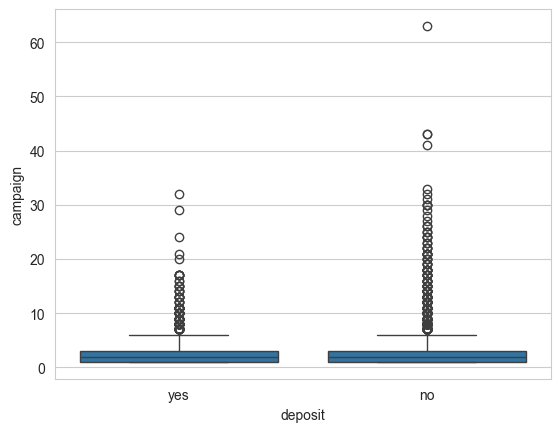

In [57]:
sns.boxplot(data=df, x='deposit', y='campaign')
plt.show()

### Number of Contacts and Deposit Subscription

The comparison suggests that customers who subscribed were generally contacted fewer times than those who did not subscribe. This may indicate that repeated contact does not necessarily improve conversion and may instead reflect lower campaign efficiency for some customer groups.

## 14. Numerical Features and Deposit Conversion

To understand how customer characteristics and campaign behavior relate to conversion, numerical variables were compared across customers who subscribed to the deposit and those who did not. This helps identify whether higher or lower values of specific features are associated with better campaign outcomes.

# 10. KEY INSIGHTS

The analysis of customer demographics, financial attributes, and campaign behavior reveals several important patterns influencing deposit subscription:

- Customers with a history of successful previous campaign interactions show significantly higher conversion rates, making prior engagement one of the strongest predictors of success.

- Contact method plays a critical role, with cellular communication showing substantially higher effectiveness compared to telephone or unknown contact types.

- Certain customer segments such as students, retired individuals, and management professionals demonstrate higher responsiveness to marketing campaigns.

- Customers with higher education levels (tertiary) tend to have better conversion rates, suggesting increased financial awareness and decision-making capability.

- Single customers show higher conversion rates compared to married customers, indicating potential differences in financial behavior and risk-taking.

- Higher account balances are generally associated with increased likelihood of deposit subscription, suggesting that financially stable customers are more inclined to invest.

- Call duration is strongly associated with conversion, indicating that customer engagement during interaction is a key driver of success.

- Increasing the number of campaign contacts does not consistently improve conversion and may indicate diminishing returns in campaign effectiveness.

# 11. Business Recommendations

Based on the analysis, the following strategic recommendations can help improve marketing campaign effectiveness:

- Prioritize customers with previous successful campaign interactions, as they have a significantly higher probability of conversion.

- Focus on cellular communication channels for outreach, as they demonstrate higher engagement and conversion rates.

- Target high-performing customer segments such as students, retired individuals, and management professionals for better campaign outcomes.

- Design personalized campaigns for customers with higher education levels, as they show stronger responsiveness to financial products.

- Improve engagement strategies during customer interactions to increase call duration, as longer interactions are strongly linked with higher conversion.

- Optimize campaign frequency by avoiding excessive repeated contacts, as higher contact frequency does not necessarily improve conversion rates.

- Segment customers based on financial strength (account balance) and prioritize high-value customers for premium offerings.

- Develop targeted strategies for low-performing segments such as blue-collar and service workers by adjusting messaging and communication approach.

# 12. Conclusion

This analysis highlights that customer conversion in marketing campaigns is influenced by a combination of demographic characteristics, financial conditions, communication methods, and past interactions.

Key factors such as previous campaign success, contact method, customer segment, and engagement level play a crucial role in determining campaign effectiveness.

By leveraging these insights, businesses can optimize targeting strategies, improve communication approaches, and enhance overall marketing performance, leading to better customer acquisition and increased return on investment.

In [66]:
df['deposit'] = df['deposit'].map({'yes': 'Yes', 'no': 'No'})

In [67]:
# Reordering columns (optional)

columns_order = [
    'age', 'age_group',
    'job', 'marital', 'education',
    'balance', 'balance_group',
    'housing', 'loan', 'default',
    'contact', 'month', 'day',
    'duration', 'campaign', 'campaign_group',
    'pdays', 'previous', 'poutcome',
    'deposit'
]

In [68]:
df = df[columns_order]

In [70]:
output_path = r"C:\Users\vasis\Desktop\Data_Analytics_Portfolio\03_Marketing_Analytics\data_cleaned\cleaned_marketing_data.csv"
df.to_csv(output_path, index=False)

# 14. Final Dataset Export

After completing data cleaning and feature engineering, the dataset was exported for further use in dashboarding and reporting. The final dataset includes additional grouped features such as age group, balance group, and campaign group, which enhance analytical insights.

The cleaned dataset is saved as `cleaned_marketing_data.csv`.